# Direct ODE Learning

In this tutorial, we will demonstrate learning the ODE extracted from the full state flow field directly.

In [ ]:
# Import all required libraries

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import warnings
from sklearn.metrics import r2_score
s
from sindy.plot_utils import visualize_ode_3d, init_plt_format
from sindy.selection import ps_stability_selection

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='Sparsity parameter is too big')
init_plt_format()

## Loading in the data

Let us load in the data from a single trajectory and visualize it.

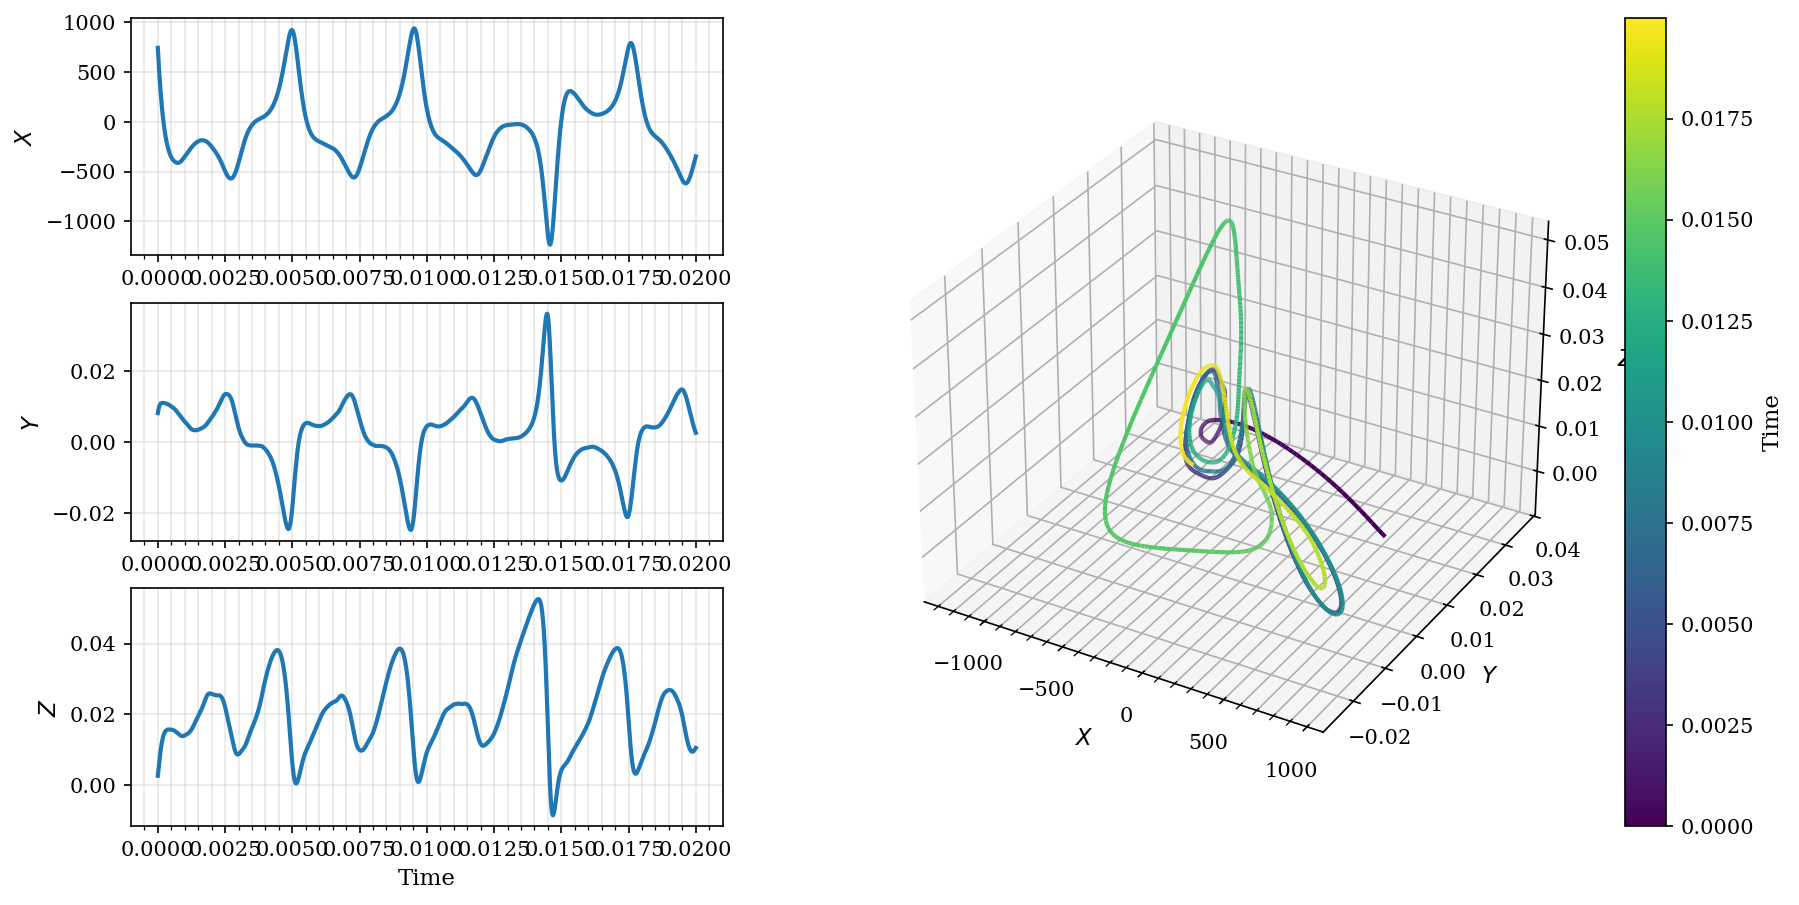

In [ ]:
data_dir: str = 'data/'
feature_names = ['X', 'Y', 'Z']

ra: float = 5e7
pr: float = 4

# Load data
data = np.load(data_dir+f"annulus_ra{ra:.3f}_pr{pr:.3f}.npz")
x = data['x'][:, :3]
t = data['t']

visualize_ode_3d(x, t, labels=feature_names)

Let us also split our data into training and validation dataset.

In [8]:
train_valid_split = 0.5

cutoff_idx: int = int(x.shape[0] * train_valid_split)

x_train = x[:cutoff_idx]
x_valid = x[cutoff_idx:]

t_train = t[:cutoff_idx]
t_valid = t[cutoff_idx:]

## Learning from a Single Trajectory

We will then apply stability selection method to identify the most suitable $\lambda$ sparsification parameter. Notice that the library columns are normalized due to the extreme difference in order of magnitude between the $L$ state and the remaining $X$ and $Y$ states. In this case, the threshold does not correspond to a hard threshold of the physical coefficients.

(1020, 3)


100%|██████████| 50/50 [00:04<00:00, 10.77it/s]


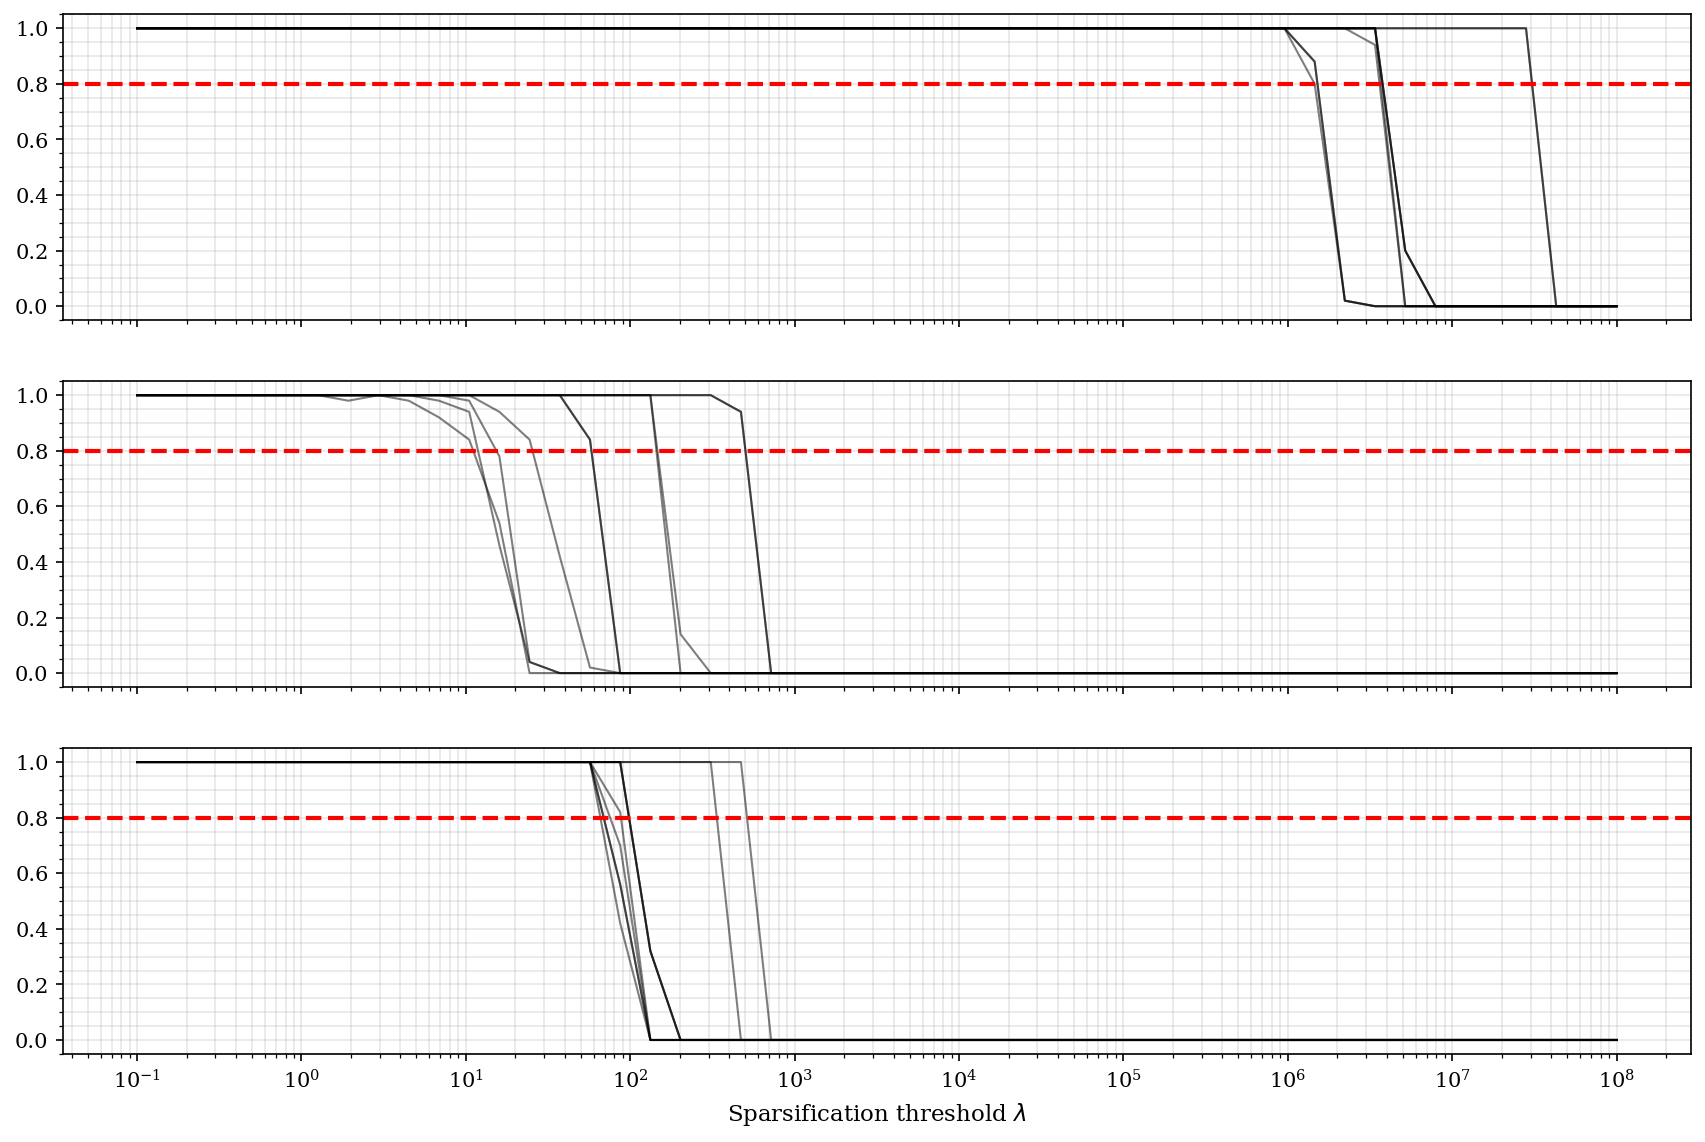

In [13]:
# Define SINDy parameters
poly_order: int = 2
include_bias: bool = True
l2_norm: float = 1e-2

# Initialise the PySINDy library to use
lib = ps.PolynomialLibrary(poly_order, include_bias=include_bias)

# Select model with stability selection
print(x_train.shape)
ps_stability_selection(
    x_train, t_train,
    l2_norm=l2_norm, ps_library=lib, normalize_columns=True
)

Similar to the previous [tutorial](/Tutorials/S3%20Annulus%20Flow/3-2%20PDE%20Learning.ipynb), different $\lambda$ values must be applied to different states. Let us apply SINDy separately to each state then concatenate the models together.

In [10]:
lambda_per_state: list[float] = [1e7, 300, 300]

models: list[ps.SINDy] = list()

lib = ps.PolynomialLibrary(poly_order, include_bias=include_bias)

for idx in range(x.shape[1]):
    opti = ps.STLSQ(lambda_per_state[idx], l2_norm, normalize_columns=True)
    model = ps.SINDy(opti, lib)
    model.fit(x_train, t_train, feature_names=feature_names)
    models.append(model)

model = models[0]

for idx in range(1, x.shape[1]):
    model.optimizer.coef_[idx] = models[idx].optimizer.coef_[idx]

model.print()

(X)' = -4414.444 X + -204771746.593 Y
(Y)' = 0.114 X + -5.807 X Z
(Z)' = 20.378 1 + 6.199 X Y


## Model Verification

The learned model can be verified using the validation data. Let us first compare the predicted time derivatives.

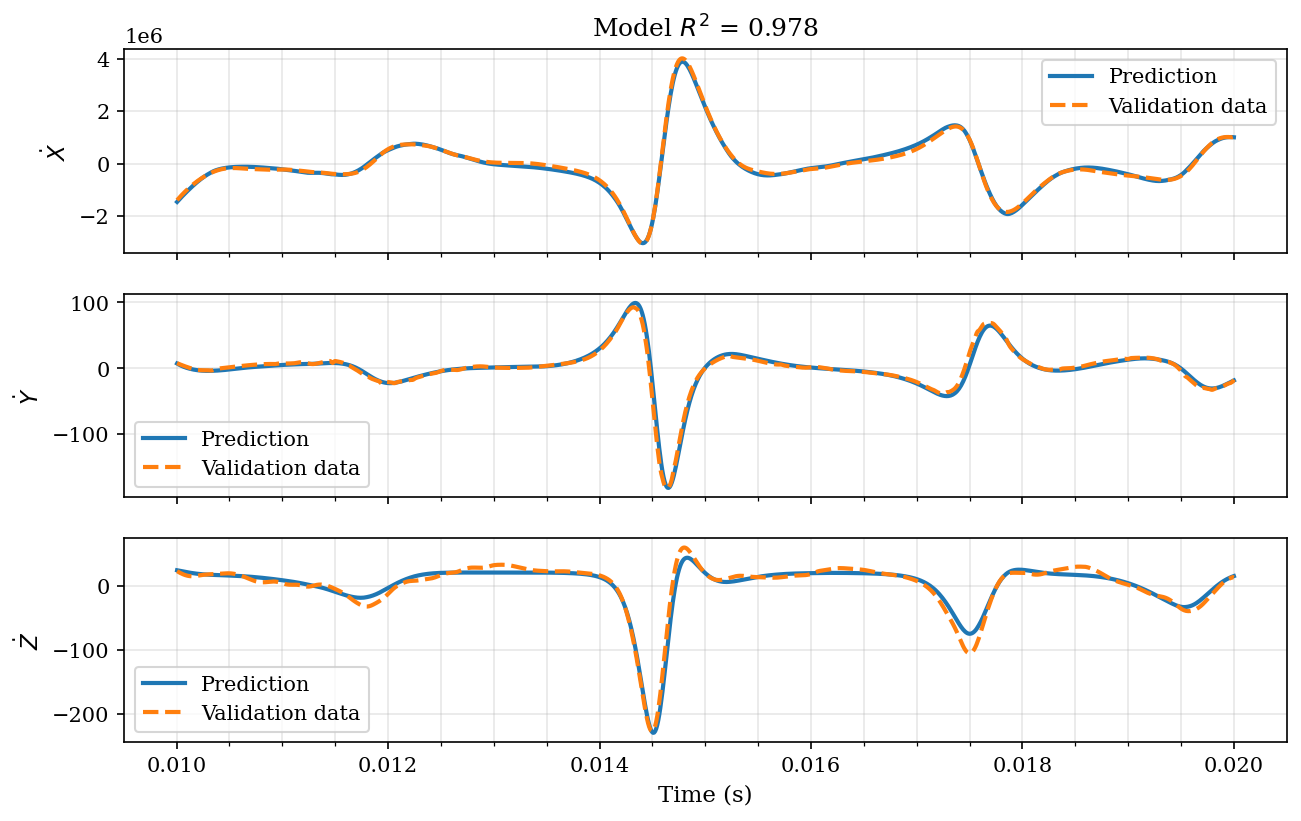

In [11]:
xdot_predict = model.predict(x_valid)
xdot_valid = ps.FiniteDifference(4)._differentiate(x_valid, t_valid)

_, axs = plt.subplots(3, 1, sharex=True, figsize=(10,6))

for idx in range(3):
    axs[idx].plot(t_valid, xdot_predict[:, idx], label='Prediction')
    axs[idx].plot(t_valid, xdot_valid[:, idx], '--', label='Validation data')
    axs[idx].set_ylabel('$\dot{' + feature_names[idx] + '}$')
    axs[idx].legend()

axs[-1].set_xlabel('Time (s)');
axs[0].set_title(f'Model $R^2$ = {r2_score(xdot_valid, xdot_predict):.3f}');

As the R2 score is close to 1.0, it represents a very accurate model. Note that R2 score here is the same as the default `score` method when called from a `SINDy` instance. Now, let us compare the resulting state trajectory when we integrate it forward in time.

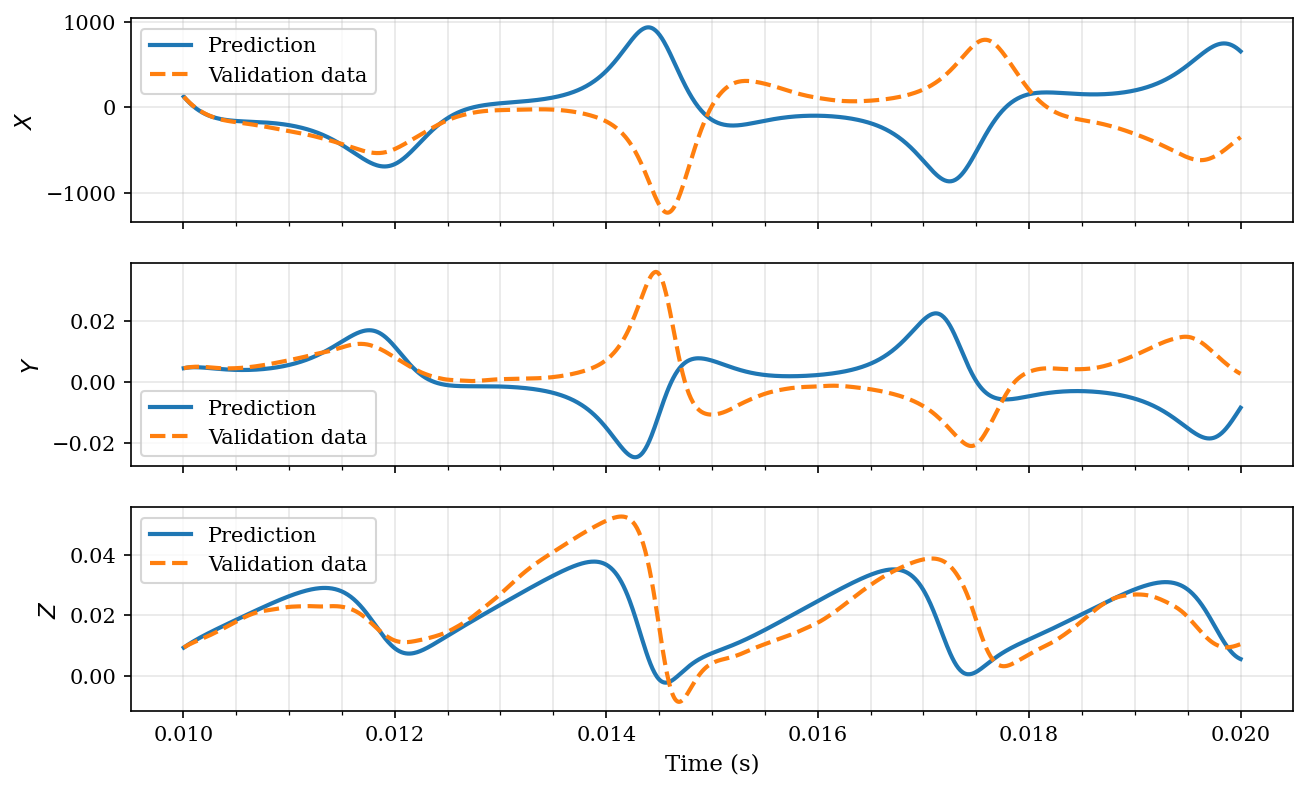

In [12]:
x_predict = model.simulate(x_valid[0], t_valid)

_, axs = plt.subplots(3, 1, sharex=True, figsize=(10,6))

for idx in range(3):
    axs[idx].plot(t_valid, x_predict[:, idx], label='Prediction')
    axs[idx].plot(t_valid, x_valid[:, idx], '--', label='Validation data')
    axs[idx].set_ylabel('$' + feature_names[idx]+ '$')
    axs[idx].legend()

axs[-1].set_xlabel('Time (s)');

Since the flow can exhibit chaotic behaviors, we can observe divergence in the resulting trajectory even if there's a near-zero error in the discovered model.

A better metric to evaluate would be the ability to identify the bifurcation mechanism from a learned parameterized SINDy model. Furthermore, the use of data with different parameters introduces richer dynamics that can be learned by SINDy and generally improves the model identification process. We shall explore more in the next tutorial.